# Original Code ( refer for falllback )

In [1]:
# """
# ============================================================
# T1.7 + T1.8 — Multi-Crop Unified Crop Disease Detection
# Kaggle Training Script
# ============================================================
# Run this in a Kaggle notebook with GPU enabled.
# Dataset: abdallahalidev/plantvillage-dataset

# Steps performed:
#   1. Load & split PlantVillage (38 classes, 54 k images)
#   2. Fine-tune MobileNetV3-Small (3 epochs, ~10 min on P100)
#   3. Export best checkpoint  →  best_model.pth
#   4. Export TFLite model     →  model.tflite  (T1.8)
#   5. Save class_names.json & disease_info.json
# """

# # ── Cell 1: Install deps ──────────────────────────────────
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "pip", "install", "-q",
#                 "timm", "torchmetrics", "matplotlib", "seaborn"], check=True)

# # ── Cell 2: Imports ───────────────────────────────────────
# import os, json, time, random, shutil
# from pathlib import Path

# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from PIL import Image

# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import DataLoader, Dataset
# from torchvision import transforms, datasets
# from torchmetrics import Accuracy, F1Score

# import timm

# SEED = 42
# random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
# DATA_ROOT  = Path("/kaggle/input/plantvillage-dataset/color")
# OUT_DIR    = Path("/kaggle/working")
# EPOCHS     = 3
# BATCH_SIZE = 64
# LR         = 3e-4
# IMG_SIZE   = 224
# print(f"Device: {DEVICE}  |  Data: {DATA_ROOT}")

# # ── Cell 3: Dataset ───────────────────────────────────────
# train_tfm = transforms.Compose([
#     transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomVerticalFlip(),
#     transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
#     transforms.RandomRotation(15),
#     transforms.ToTensor(),
#     transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
# ])

# val_tfm = transforms.Compose([
#     transforms.Resize(256),
#     transforms.CenterCrop(IMG_SIZE),
#     transforms.ToTensor(),
#     transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
# ])

# full_ds = datasets.ImageFolder(DATA_ROOT)
# CLASS_NAMES = full_ds.classes
# NUM_CLASSES = len(CLASS_NAMES)
# print(f"Classes: {NUM_CLASSES}  |  Total images: {len(full_ds)}")

# # 80/10/10 split
# n = len(full_ds)
# n_train = int(0.8 * n)
# n_val   = int(0.1 * n)
# n_test  = n - n_train - n_val
# train_idx, val_idx, test_idx = torch.utils.data.random_split(
#     range(n), [n_train, n_val, n_test],
#     generator=torch.Generator().manual_seed(SEED))

# class SubsetWithTransform(Dataset):
#     def __init__(self, base_ds, indices, tfm):
#         self.base = base_ds; self.idx = list(indices); self.tfm = tfm
#     def __len__(self): return len(self.idx)
#     def __getitem__(self, i):
#         img, lbl = self.base[self.idx[i]]
#         return self.tfm(img), lbl

# train_ds = SubsetWithTransform(full_ds, train_idx, train_tfm)
# val_ds   = SubsetWithTransform(full_ds, val_idx,   val_tfm)
# test_ds  = SubsetWithTransform(full_ds, test_idx,  val_tfm)

# train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
#                           num_workers=4, pin_memory=True)
# val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
#                           num_workers=4, pin_memory=True)
# test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
#                           num_workers=4, pin_memory=True)

# # ── Cell 4: Model ─────────────────────────────────────────
# model = timm.create_model("mobilenetv3_small_100", pretrained=True,
#                            num_classes=NUM_CLASSES)
# model = model.to(DEVICE)

# # Two-stage: freeze backbone, train head for 1 epoch, then unfreeze
# for name, p in model.named_parameters():
#     if "classifier" not in name:
#         p.requires_grad = False

# criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
# optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
#                         lr=LR, weight_decay=1e-4)
# scheduler = optim.lr_scheduler.OneCycleLR(
#     optimizer, max_lr=LR,
#     steps_per_epoch=len(train_loader), epochs=EPOCHS)

# acc_metric = Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(DEVICE)
# f1_metric  = F1Score(task="multiclass",  num_classes=NUM_CLASSES,
#                      average="macro").to(DEVICE)

# # ── Cell 5: Training loop ─────────────────────────────────
# history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
# best_acc = 0.0

# for epoch in range(1, EPOCHS + 1):
#     # Unfreeze all at epoch 2
#     if epoch == 2:
#         for p in model.parameters():
#             p.requires_grad = True
#         optimizer = optim.AdamW(model.parameters(), lr=LR/5, weight_decay=1e-4)
#         scheduler = optim.lr_scheduler.OneCycleLR(
#             optimizer, max_lr=LR/5,
#             steps_per_epoch=len(train_loader), epochs=EPOCHS - 1)

#     # ── Train ──
#     model.train(); train_loss = 0.0
#     for imgs, lbls in train_loader:
#         imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
#         optimizer.zero_grad()
#         loss = criterion(model(imgs), lbls)
#         loss.backward(); optimizer.step(); scheduler.step()
#         train_loss += loss.item()
#     train_loss /= len(train_loader)

#     # ── Validate ──
#     model.eval(); val_loss = 0.0
#     acc_metric.reset(); f1_metric.reset()
#     with torch.no_grad():
#         for imgs, lbls in val_loader:
#             imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
#             logits = model(imgs)
#             val_loss += criterion(logits, lbls).item()
#             preds = logits.argmax(1)
#             acc_metric.update(preds, lbls)
#             f1_metric.update(preds, lbls)
#     val_loss /= len(val_loader)
#     val_acc = acc_metric.compute().item()
#     val_f1  = f1_metric.compute().item()

#     history["train_loss"].append(train_loss)
#     history["val_loss"].append(val_loss)
#     history["val_acc"].append(val_acc)
#     history["val_f1"].append(val_f1)

#     print(f"Epoch {epoch}/{EPOCHS}  "
#           f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
#           f"val_acc={val_acc:.4f}  val_f1={val_f1:.4f}")

#     if val_acc > best_acc:
#         best_acc = val_acc
#         torch.save({"epoch": epoch,
#                     "model_state_dict": model.state_dict(),
#                     "val_acc": val_acc,
#                     "class_names": CLASS_NAMES},
#                    OUT_DIR / "best_model.pth")
#         print(f"  ✓ Saved best model (val_acc={val_acc:.4f})")

# # ── Cell 6: Test evaluation ───────────────────────────────
# ckpt = torch.load(OUT_DIR / "best_model.pth")
# model.load_state_dict(ckpt["model_state_dict"])
# model.eval()
# acc_metric.reset(); f1_metric.reset()
# with torch.no_grad():
#     for imgs, lbls in test_loader:
#         imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
#         preds = model(imgs).argmax(1)
#         acc_metric.update(preds, lbls)
#         f1_metric.update(preds, lbls)
# test_acc = acc_metric.compute().item()
# test_f1  = f1_metric.compute().item()
# print(f"\nTest  acc={test_acc:.4f}  f1={test_f1:.4f}")

# # ── Cell 7: Plot training curves ─────────────────────────
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# axes[0].plot(history["train_loss"], label="Train")
# axes[0].plot(history["val_loss"],   label="Val")
# axes[0].set_title("Loss"); axes[0].legend()
# axes[1].plot(history["val_acc"],  label="Acc")
# axes[1].plot(history["val_f1"],   label="F1")
# axes[1].set_title("Metrics"); axes[1].legend()
# plt.tight_layout()
# plt.savefig(OUT_DIR / "training_curves.png", dpi=150)
# plt.show()

# # ── Cell 8: Save class names ──────────────────────────────
# with open(OUT_DIR / "class_names.json", "w") as f:
#     json.dump(CLASS_NAMES, f, indent=2)
# print("Saved class_names.json")

# # ── Cell 9: TFLite export (T1.8) ─────────────────────────
# """
# Export MobileNetV3-Small to ONNX → TFLite for mobile deployment.
# Requires: onnx, onnx2tf (or tf2onnx), tensorflow
# """
# try:
#     subprocess.run([sys.executable, "-m", "pip", "install", "-q",
#                     "onnx", "onnxruntime", "onnx2tf", "tensorflow"], check=True)
#     import onnx
#     import onnx2tf

#     # Export to ONNX first
#     dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
#     onnx_path = str(OUT_DIR / "model.onnx")
#     torch.onnx.export(
#         model.cpu(), dummy.cpu(), onnx_path,
#         input_names=["input"], output_names=["output"],
#         dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}},
#         opset_version=17)
#     print("ONNX export OK")

#     # Convert ONNX → TFLite
#     onnx2tf.convert(
#         input_onnx_file_path=onnx_path,
#         output_folder_path=str(OUT_DIR / "tflite_model"),
#         output_tfv5_pb=True,
#         not_use_onnxsim=False)
#     print("TFLite export OK → tflite_model/")
# except Exception as e:
#     print(f"TFLite export skipped: {e}")

# print("\n=== DONE ===")
# print(f"Artifacts in {OUT_DIR}:")
# for p in sorted(OUT_DIR.iterdir()):
#     print(f"  {p.name}")

# Code execution from here

In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "timm", "torchmetrics", "matplotlib", "seaborn"], check=True)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'timm', 'torchmetrics', 'matplotlib', 'seaborn'], returncode=0)

In [2]:
import os, json, time, random, shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
from torchmetrics import Accuracy, F1Score

import timm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)



DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
DATA_ROOT  = Path("/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color")
OUT_DIR    = Path("/kaggle/working")
EPOCHS     = 3
BATCH_SIZE = 64
LR         = 3e-4
IMG_SIZE   = 224
print(f"Device: {DEVICE}  |  Data: {DATA_ROOT}")

Device: cuda  |  Data: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color


In [3]:
train_tfm = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_tfm = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

full_ds = datasets.ImageFolder(DATA_ROOT)
CLASS_NAMES = full_ds.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes: {NUM_CLASSES}  |  Total images: {len(full_ds)}")

# 80/10/10 split
n = len(full_ds)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)
n_test  = n - n_train - n_val
train_idx, val_idx, test_idx = torch.utils.data.random_split(
    range(n), [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED))

class SubsetWithTransform(Dataset):
    def __init__(self, base_ds, indices, tfm):
        self.base = base_ds; self.idx = list(indices); self.tfm = tfm
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        img, lbl = self.base[self.idx[i]]
        return self.tfm(img), lbl

train_ds = SubsetWithTransform(full_ds, train_idx, train_tfm)
val_ds   = SubsetWithTransform(full_ds, val_idx,   val_tfm)
test_ds  = SubsetWithTransform(full_ds, test_idx,  val_tfm)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

Classes: 38  |  Total images: 54305


In [4]:
model = timm.create_model("mobilenetv3_small_100", pretrained=True,
                           num_classes=NUM_CLASSES)
model = model.to(DEVICE)

# Two-stage: freeze backbone, train head for 1 epoch, then unfreeze
for name, p in model.named_parameters():
    if "classifier" not in name:
        p.requires_grad = False

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR,
    steps_per_epoch=len(train_loader), epochs=EPOCHS)

acc_metric = Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(DEVICE)
f1_metric  = F1Score(task="multiclass",  num_classes=NUM_CLASSES,
                     average="macro").to(DEVICE)

model.safetensors:   0%|          | 0.00/10.2M [00:00<?, ?B/s]

In [5]:
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
best_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    # Unfreeze all at epoch 2
    if epoch == 2:
        for p in model.parameters():
            p.requires_grad = True
        optimizer = optim.AdamW(model.parameters(), lr=LR/5, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=LR/5,
            steps_per_epoch=len(train_loader), epochs=EPOCHS - 1)

    # ── Train ──
    model.train(); train_loss = 0.0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward(); optimizer.step(); scheduler.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval(); val_loss = 0.0
    acc_metric.reset(); f1_metric.reset()
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            logits = model(imgs)
            val_loss += criterion(logits, lbls).item()
            preds = logits.argmax(1)
            acc_metric.update(preds, lbls)
            f1_metric.update(preds, lbls)
    val_loss /= len(val_loader)
    val_acc = acc_metric.compute().item()
    val_f1  = f1_metric.compute().item()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch}/{EPOCHS}  "
          f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
          f"val_acc={val_acc:.4f}  val_f1={val_f1:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({"epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "val_acc": val_acc,
                    "class_names": CLASS_NAMES},
                   OUT_DIR / "best_model.pth")
        print(f"  ✓ Saved best model (val_acc={val_acc:.4f})")

Epoch 1/3  train_loss=2.9621  val_loss=1.8618  val_acc=0.6155  val_f1=0.4694
  ✓ Saved best model (val_acc=0.6155)
Epoch 2/3  train_loss=1.1068  val_loss=0.9351  val_acc=0.9460  val_f1=0.9222
  ✓ Saved best model (val_acc=0.9460)
Epoch 3/3  train_loss=0.8338  val_loss=0.8491  val_acc=0.9703  val_f1=0.9563
  ✓ Saved best model (val_acc=0.9703)


In [6]:
ckpt = torch.load(OUT_DIR / "best_model.pth")
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
acc_metric.reset(); f1_metric.reset()
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        preds = model(imgs).argmax(1)
        acc_metric.update(preds, lbls)
        f1_metric.update(preds, lbls)
test_acc = acc_metric.compute().item()
test_f1  = f1_metric.compute().item()
print(f"\nTest  acc={test_acc:.4f}  f1={test_f1:.4f}")


Test  acc=0.9702  f1=0.9647


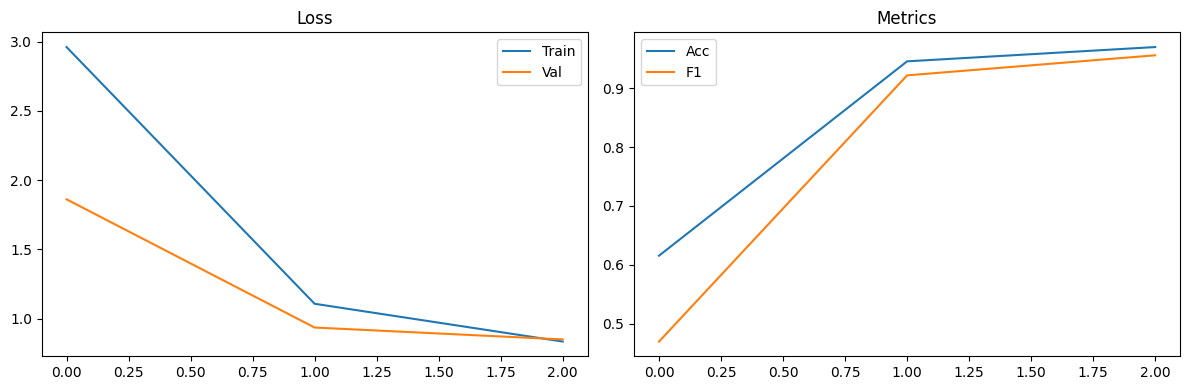

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history["val_acc"],  label="Acc")
axes[1].plot(history["val_f1"],   label="F1")
axes[1].set_title("Metrics"); axes[1].legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "training_curves.png", dpi=150)
plt.show()


In [8]:
with open(OUT_DIR / "class_names.json", "w") as f:
    json.dump(CLASS_NAMES, f, indent=2)
print("Saved class_names.json")

Saved class_names.json


In [9]:
"""
Export MobileNetV3-Small to ONNX → TFLite for mobile deployment.
Requires: onnx, onnx2tf (or tf2onnx), tensorflow
"""
try:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "onnx", "onnxruntime", "onnx2tf", "tensorflow"], check=True)
    import onnx
    import onnx2tf

    # Export to ONNX first
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    onnx_path = str(OUT_DIR / "model.onnx")
    torch.onnx.export(
        model.cpu(), dummy.cpu(), onnx_path,
        input_names=["input"], output_names=["output"],
        dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}},
        opset_version=17)
    print("ONNX export OK")

    # Convert ONNX → TFLite
    onnx2tf.convert(
        input_onnx_file_path=onnx_path,
        output_folder_path=str(OUT_DIR / "tflite_model"),
        output_tfv5_pb=True,
        not_use_onnxsim=False)
    print("TFLite export OK → tflite_model/")
except Exception as e:
    print(f"TFLite export skipped: {e}")

print("\n=== DONE ===")
print(f"Artifacts in {OUT_DIR}:")
for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.2/223.2 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 112.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
a2a-sdk 0.3.25 requires protobuf>=5.29.5, but you have protobuf 4.25.5 which is incompatible.
kaggle-environments 1.27.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.5 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 wh

[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Runtim

Applied 69 of general pattern rewrite rules.
ONNX export OK
TFLite export skipped: convert() got an unexpected keyword argument 'output_tfv5_pb'

=== DONE ===
Artifacts in /kaggle/working:
  .virtual_documents
  best_model.pth
  class_names.json
  model.onnx
  model.onnx.data
  training_curves.png


# Testing

In [3]:
import os
import shutil
import zipfile
from pathlib import Path

# Define paths
input_dir = Path('/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color')
output_zip = 'plantvillage_sample.zip'
temp_folder = 'sample_images'

# Create a temporary directory to store the selection
if os.path.exists(temp_folder):
    shutil.rmtree(temp_folder)
os.makedirs(temp_folder)

print("Selecting images...")

# Iterate through each class directory
for class_dir in sorted(os.listdir(input_dir)):
    class_path = input_dir / class_dir
    
    if os.path.isdir(class_path):
        # Create corresponding folder in temp directory
        target_class_dir = os.path.join(temp_folder, class_dir)
        os.makedirs(target_class_dir, exist_ok=True)
        
        # Get list of images and take the first 2
        images = [f for f in os.listdir(class_path) if os.path.isfile(class_path / f)]
        sample_images = images[:2]
        
        for img_name in sample_images:
            shutil.copy(class_path / img_name, os.path.join(target_class_dir, img_name))

# Create the Zip file
print(f"Creating {output_zip}...")
with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(temp_folder):
        for file in files:
            # Write file to zip, maintaining folder structure but removing the 'temp_folder' prefix
            rel_path = os.path.relpath(os.path.join(root, file), temp_folder)
            zipf.write(os.path.join(root, file), rel_path)

# Clean up the temporary folder
shutil.rmtree(temp_folder)
print(f"Done! You can find '{output_zip}' in the /kaggle/working directory.")

Selecting images...
Creating plantvillage_sample.zip...
Done! You can find 'plantvillage_sample.zip' in the /kaggle/working directory.
